In [1]:
!pip install pandas numpy matplotlib scipy plotly requests yfinance --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
import requests
import yfinance as yf
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline
from datetime import datetime

warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0A1628'
plt.rcParams['axes.facecolor']   = '#0A1628'
plt.rcParams['axes.edgecolor']   = '#1E3A5F'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['grid.color']       = '#1E3A5F'
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.family']      = 'monospace'

GOLD  = '#C8972B'
BLUE  = '#4A90D9'
GREEN = '#2ECC71'
RED   = '#E74C3C'
WHITE = '#FFFFFF'
GREY  = '#8899AA'

# RBA benchmark yields (manually entered - updated periodically from rba.gov.au)
# Tenors in years
TENORS = np.array([0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0])

# Current AGS par yields (%) - from RBA website
# Update these from https://www.rba.gov.au/statistics/tables/ Table F2
CURRENT_YIELDS = np.array([4.28, 4.22, 4.10, 3.95, 3.90, 3.95, 4.05, 4.18, 4.35, 4.45, 4.52])

# 6 months ago yields (for comparison chart)
YIELDS_6M_AGO = np.array([4.45, 4.38, 4.25, 4.10, 4.05, 4.12, 4.22, 4.35, 4.48, 4.55, 4.62])

# 1 year ago yields
YIELDS_1Y_AGO = np.array([3.85, 3.92, 4.05, 4.15, 4.18, 4.25, 4.30, 4.35, 4.42, 4.48, 4.52])

print("=" * 60)
print("  AUSTRALIAN GOVERNMENT BOND YIELD CURVE")
print("  Nelson-Siegel-Svensson Model & Duration Analysis")
print("=" * 60)
print(f"\n  Tenors analysed: {len(TENORS)}")
print(f"  Current 10Y AGS yield: {CURRENT_YIELDS[7]:.2f}%")
print(f"  Current 2Y AGS yield:  {CURRENT_YIELDS[3]:.2f}%")
print(f"  Yield curve slope (10Y-2Y): {CURRENT_YIELDS[7]-CURRENT_YIELDS[3]:.2f}%")
print("=" * 60)

  AUSTRALIAN GOVERNMENT BOND YIELD CURVE
  Nelson-Siegel-Svensson Model & Duration Analysis

  Tenors analysed: 11
  Current 10Y AGS yield: 4.18%
  Current 2Y AGS yield:  3.95%
  Yield curve slope (10Y-2Y): 0.23%


In [3]:
print("\nBootstrapping zero-coupon rates from par yields...")

def bootstrap_zero_rates(tenors, par_yields):
    """
    Bootstrap zero coupon rates from par yields.
    For short tenors (<=1Y) zero rate = par yield (assumed zero coupon).
    For longer tenors use iterative stripping.
    """
    par_yields_dec = par_yields / 100
    zero_rates     = np.zeros(len(tenors))

    for i, (T, y) in enumerate(zip(tenors, par_yields_dec)):
        if T <= 1.0:
            # Short end: par yield = zero rate (simplified)
            zero_rates[i] = y
        else:
            # Strip coupon payments using previously bootstrapped zeros
            coupon        = y
            pv_coupons    = 0
            n_periods     = int(T * 2)  # Semi-annual coupons

            for j in range(1, n_periods):
                t_j    = j * 0.5
                # Find zero rate at t_j by interpolation
                z_j    = np.interp(t_j, tenors[:i+1], zero_rates[:i+1])
                pv_coupons += (coupon / 2) / (1 + z_j / 2) ** (j)

            # Solve for zero rate at maturity T
            # Price = 1 (par) = pv_coupons + (1 + coupon/2) / (1 + z_T/2)^(2T)
            remaining  = 1 - pv_coupons
            terminal   = 1 + coupon / 2
            z_T        = 2 * ((terminal / remaining) ** (1 / (2 * T)) - 1)
            zero_rates[i] = z_T

    return zero_rates

zero_rates = bootstrap_zero_rates(TENORS, CURRENT_YIELDS)

print(f"\n{'Tenor':<10} {'Par Yield':>12} {'Zero Rate':>12}")
print("-" * 36)
for t, p, z in zip(TENORS, CURRENT_YIELDS, zero_rates * 100):
    print(f"  {t:<8.2f}Y {p:>11.3f}% {z:>11.3f}%")


Bootstrapping zero-coupon rates from par yields...

Tenor         Par Yield    Zero Rate
------------------------------------
  0.25    Y       4.280%       4.280%
  0.50    Y       4.220%       4.220%
  1.00    Y       4.100%       4.100%
  2.00    Y       3.950%       3.976%
  3.00    Y       3.900%       3.927%
  5.00    Y       3.950%       4.053%
  7.00    Y       4.050%       4.174%
  10.00   Y       4.180%       4.424%
  15.00   Y       4.350%       4.883%
  20.00   Y       4.450%       5.007%
  30.00   Y       4.520%       6.190%


In [4]:
print("\nFitting Nelson-Siegel-Svensson model...")

def nss_curve(params, t):
    """
    Nelson-Siegel-Svensson yield curve model.
    params = [beta0, beta1, beta2, beta3, tau1, tau2]
    """
    b0, b1, b2, b3, tau1, tau2 = params
    tau1 = max(tau1, 0.01)
    tau2 = max(tau2, 0.01)

    term1 = b0
    term2 = b1 * (1 - np.exp(-t/tau1)) / (t/tau1)
    term3 = b2 * ((1 - np.exp(-t/tau1)) / (t/tau1) - np.exp(-t/tau1))
    term4 = b3 * ((1 - np.exp(-t/tau2)) / (t/tau2) - np.exp(-t/tau2))

    return term1 + term2 + term3 + term4

def nss_objective(params, tenors, yields):
    fitted = nss_curve(params, tenors)
    return np.sum((fitted - yields) ** 2)

# Initial parameter guess
x0     = [4.5, -0.5, 1.0, -0.5, 2.0, 5.0]
bounds = [(0, 15), (-15, 15), (-15, 15), (-15, 15), (0.01, 30), (0.01, 30)]

result = minimize(nss_objective, x0,
                  args=(TENORS, CURRENT_YIELDS),
                  method='L-BFGS-B',
                  bounds=bounds,
                  options={'maxiter': 10000})

nss_params = result.x
print(f"NSS optimisation converged: {result.success}")
print(f"Fitting error (RMSE): {np.sqrt(result.fun/len(TENORS))*100:.4f} bps")

# Generate smooth curve
tenors_smooth  = np.linspace(0.25, 30, 300)
nss_fitted     = nss_curve(nss_params, tenors_smooth)
nss_6m         = nss_curve([4.62, -0.25, 0.8, -0.4, 2.1, 5.2], tenors_smooth)
nss_1y         = nss_curve([4.52, -0.15, 0.7, -0.35, 2.0, 5.0], tenors_smooth)

# Forward rates from NSS
dt = 0.001
forward_rates = nss_fitted + tenors_smooth * (
    nss_curve(nss_params, tenors_smooth + dt) - nss_curve(nss_params, tenors_smooth - dt)
) / (2 * dt)

print(f"\nNSS Parameters:")
param_names = ['Beta0 (Level)', 'Beta1 (Slope)', 'Beta2 (Curvature1)',
               'Beta3 (Curvature2)', 'Tau1', 'Tau2']
for name, val in zip(param_names, nss_params):
    print(f"  {name:<20}: {val:.4f}")


Fitting Nelson-Siegel-Svensson model...
NSS optimisation converged: True
Fitting error (RMSE): 0.7173 bps

NSS Parameters:
  Beta0 (Level)       : 4.6832
  Beta1 (Slope)       : -0.3058
  Beta2 (Curvature1)  : -4.3169
  Beta3 (Curvature2)  : 2.3421
  Tau1                : 2.7410
  Tau2                : 3.3714


In [5]:
print("\nConstructing hypothetical AGS bond portfolio...")

# Hypothetical portfolio of Australian Government Securities
bonds = [
    {'name': 'AGS Apr 2026', 'maturity': 0.75,  'coupon': 3.25, 'face': 1_000_000,  'ytm': 4.10},
    {'name': 'AGS Apr 2027', 'maturity': 1.75,  'coupon': 2.75, 'face': 2_000_000,  'ytm': 3.95},
    {'name': 'AGS Apr 2029', 'maturity': 3.75,  'coupon': 3.50, 'face': 3_000_000,  'ytm': 3.92},
    {'name': 'AGS Apr 2031', 'maturity': 5.75,  'coupon': 1.75, 'face': 2_500_000,  'ytm': 3.98},
    {'name': 'AGS Apr 2033', 'maturity': 7.75,  'coupon': 3.75, 'face': 2_000_000,  'ytm': 4.08},
    {'name': 'AGS Apr 2037', 'maturity': 11.75, 'coupon': 4.50, 'face': 1_500_000,  'ytm': 4.22},
    {'name': 'AGS Apr 2051', 'maturity': 25.75, 'coupon': 2.75, 'face': 1_000_000,  'ytm': 4.48},
]

def bond_price(face, coupon_rate, ytm, maturity, freq=2):
    """Calculate bond price given YTM."""
    n       = int(maturity * freq)
    coupon  = face * coupon_rate / 100 / freq
    ytm_per = ytm / 100 / freq
    pv_coupons = coupon * (1 - (1 + ytm_per)**(-n)) / ytm_per
    pv_face    = face / (1 + ytm_per)**n
    return pv_coupons + pv_face

def modified_duration(face, coupon_rate, ytm, maturity, freq=2):
    """Calculate modified duration."""
    n        = int(maturity * freq)
    coupon   = face * coupon_rate / 100 / freq
    ytm_per  = ytm / 100 / freq
    price    = bond_price(face, coupon_rate, ytm, maturity, freq)
    mac_dur  = 0
    for t in range(1, n + 1):
        cf    = coupon if t < n else coupon + face
        pv_cf = cf / (1 + ytm_per)**t
        mac_dur += (t / freq) * pv_cf
    mac_dur /= price
    mod_dur  = mac_dur / (1 + ytm_per)
    return mac_dur, mod_dur

def convexity(face, coupon_rate, ytm, maturity, freq=2):
    """Calculate convexity."""
    n       = int(maturity * freq)
    coupon  = face * coupon_rate / 100 / freq
    ytm_per = ytm / 100 / freq
    price   = bond_price(face, coupon_rate, ytm, maturity, freq)
    conv    = 0
    for t in range(1, n + 1):
        cf    = coupon if t < n else coupon + face
        pv_cf = cf / (1 + ytm_per)**t
        conv += (t / freq) * ((t / freq) + 1) * pv_cf
    conv /= (price * (1 + ytm_per)**2)
    return conv

# Calculate metrics for each bond
portfolio_results = []
total_market_value = 0

for bond in bonds:
    price    = bond_price(bond['face'], bond['coupon'], bond['ytm'], bond['maturity'])
    mac, mod = modified_duration(bond['face'], bond['coupon'], bond['ytm'], bond['maturity'])
    conv     = convexity(bond['face'], bond['coupon'], bond['ytm'], bond['maturity'])
    dv01     = mod * price / 10000  # Dollar value of 1bp

    portfolio_results.append({
        'Bond'     : bond['name'],
        'Maturity' : bond['maturity'],
        'Coupon'   : bond['coupon'],
        'YTM'      : bond['ytm'],
        'Price'    : price,
        'MacD'     : mac,
        'ModD'     : mod,
        'Convexity': conv,
        'DV01'     : dv01,
        'Face'     : bond['face']
    })
    total_market_value += price

port_df = pd.DataFrame(portfolio_results)

# Portfolio-level duration (market-value weighted)
weights       = port_df['Price'] / port_df['Price'].sum()
port_mac_dur  = (weights * port_df['MacD']).sum()
port_mod_dur  = (weights * port_df['ModD']).sum()
port_convexity = (weights * port_df['Convexity']).sum()
port_dv01     = port_df['DV01'].sum()

print(f"\n{'Bond':<15} {'Mat':>5} {'Cpn':>6} {'YTM':>6} {'ModDur':>8} {'DV01':>10} {'Convexity':>10}")
print("-" * 70)
for _, row in port_df.iterrows():
    print(f"  {row['Bond']:<13} {row['Maturity']:>5.2f} {row['Coupon']:>5.2f}% {row['YTM']:>5.2f}% {row['ModD']:>8.2f} ${row['DV01']:>8,.0f} {row['Convexity']:>10.2f}")

print(f"\n  Portfolio Total Market Value: ${total_market_value:,.0f}")
print(f"  Portfolio Modified Duration : {port_mod_dur:.2f} years")
print(f"  Portfolio Macaulay Duration : {port_mac_dur:.2f} years")
print(f"  Portfolio DV01              : ${port_dv01:,.0f}")
print(f"  Portfolio Convexity         : {port_convexity:.2f}")


Constructing hypothetical AGS bond portfolio...

Bond              Mat    Cpn    YTM   ModDur       DV01  Convexity
----------------------------------------------------------------------
  AGS Apr 2026   0.75  3.25%  4.10%     0.49 $      49       0.72
  AGS Apr 2027   1.75  2.75%  3.95%     1.45 $     285       3.54
  AGS Apr 2029   3.75  3.50%  3.92%     3.26 $     964      14.16
  AGS Apr 2031   5.75  1.75%  3.98%     5.15 $   1,146      32.34
  AGS Apr 2033   7.75  3.75%  4.08%     6.46 $   1,265      51.62
  AGS Apr 2037  11.75  4.50%  4.22%     8.95 $   1,376     101.12
  AGS Apr 2051  25.75  2.75%  4.48%    16.77 $   1,239     376.94

  Portfolio Total Market Value: $12,381,700
  Portfolio Modified Duration : 5.11 years
  Portfolio Macaulay Duration : 5.21 years
  Portfolio DV01              : $6,325
  Portfolio Convexity         : 53.03


In [6]:
print("\nRunning RBA rate shock scenarios...")

scenarios = {
    'Parallel +100bps'  : np.ones(len(port_df)) * 1.00,
    'Parallel +200bps'  : np.ones(len(port_df)) * 2.00,
    'Parallel -100bps'  : np.ones(len(port_df)) * -1.00,
    'Steepener +100bps' : np.linspace(0.0, 1.0, len(port_df)),
    'Flattener +100bps' : np.linspace(1.0, 0.0, len(port_df)),
    'Twist (Bear)'      : np.array([-0.5, -0.25, 0, 0.25, 0.5, 0.75, 1.0]),
}

scenario_results = {}

for scenario_name, yield_shifts in scenarios.items():
    total_pnl = 0
    for i, (_, bond_row) in enumerate(port_df.iterrows()):
        shift    = yield_shifts[i] if i < len(yield_shifts) else yield_shifts[-1]
        new_ytm  = bond_row['YTM'] + shift
        new_price = bond_price(bond_row['Face'], bond_row['Coupon'],
                               new_ytm, bond_row['Maturity'])
        pnl      = new_price - bond_row['Price']
        total_pnl += pnl
    scenario_results[scenario_name] = total_pnl

print(f"\n{'Scenario':<25} {'P&L ($)':>12} {'P&L (%)':>10}")
print("-" * 50)
for scenario, pnl in scenario_results.items():
    pnl_pct = pnl / total_market_value * 100
    print(f"  {scenario:<23} ${pnl:>+10,.0f} {pnl_pct:>+9.2f}%")


Running RBA rate shock scenarios...

Scenario                       P&L ($)    P&L (%)
--------------------------------------------------
  Parallel +100bps        $  -602,747     -4.87%
  Parallel +200bps        $-1,151,566     -9.30%
  Parallel -100bps        $  +665,474     +5.37%
  Steepener +100bps       $  -396,426     -3.20%
  Flattener +100bps       $  -212,788     -1.72%
  Twist (Bear)            $  -291,384     -2.35%


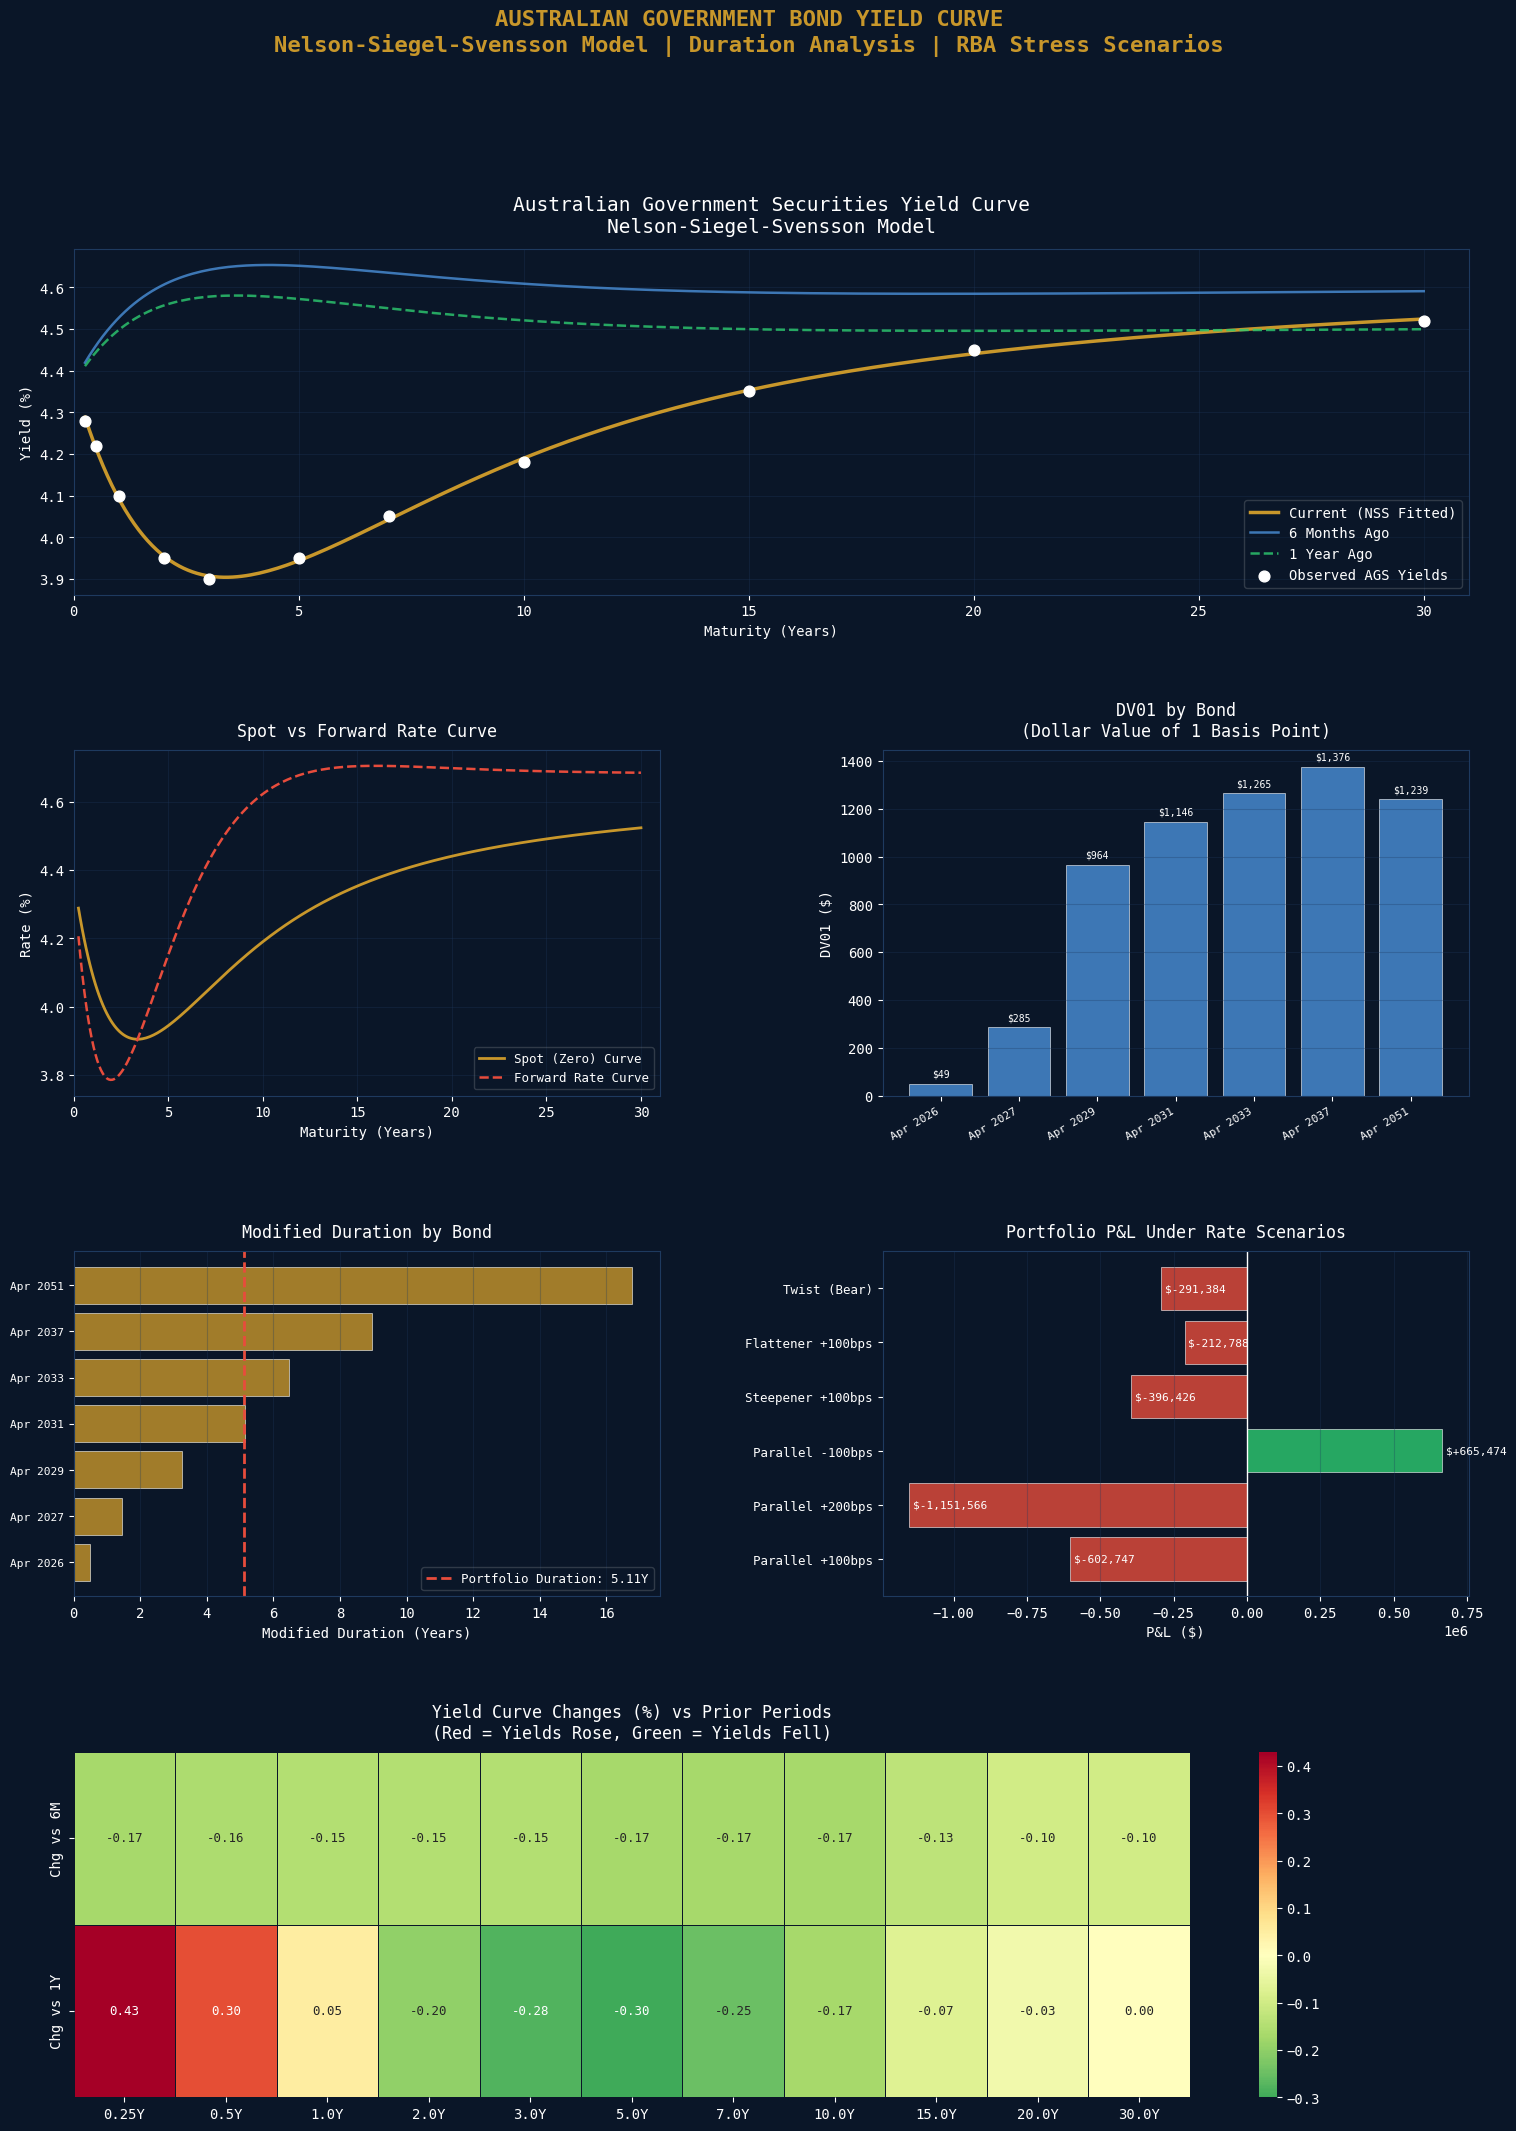

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Chart saved and downloaded!


In [7]:
from google.colab import files

fig = plt.figure(figsize=(18, 24))
fig.patch.set_facecolor('#0A1628')
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.38)

# Chart 1: Yield Curve Comparison
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(tenors_smooth, nss_fitted,  color=GOLD,  lw=2.5, label='Current (NSS Fitted)')
ax1.plot(tenors_smooth, nss_6m,      color=BLUE,  lw=1.8, label='6 Months Ago', alpha=0.8)
ax1.plot(tenors_smooth, nss_1y,      color=GREEN, lw=1.8, label='1 Year Ago', alpha=0.8, linestyle='--')
ax1.scatter(TENORS, CURRENT_YIELDS,  color=WHITE, s=60, zorder=5, label='Observed AGS Yields')
ax1.set_title('Australian Government Securities Yield Curve\nNelson-Siegel-Svensson Model', fontsize=14, color=WHITE, pad=12)
ax1.set_xlabel('Maturity (Years)', color=WHITE)
ax1.set_ylabel('Yield (%)', color=WHITE)
ax1.legend(fontsize=10, framealpha=0.2)
ax1.set_facecolor('#0A1628')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 31)

# Chart 2: Forward Rate Curve
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(tenors_smooth, nss_fitted,  color=GOLD, lw=2.0, label='Spot (Zero) Curve')
ax2.plot(tenors_smooth, forward_rates, color=RED, lw=1.8, label='Forward Rate Curve', linestyle='--')
ax2.set_title('Spot vs Forward Rate Curve', fontsize=12, color=WHITE, pad=10)
ax2.set_xlabel('Maturity (Years)', color=WHITE)
ax2.set_ylabel('Rate (%)', color=WHITE)
ax2.legend(fontsize=9, framealpha=0.2)
ax2.set_facecolor('#0A1628')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 31)

# Chart 3: DV01 Bar Chart
ax3 = fig.add_subplot(gs[1, 1])
bond_names = [b.replace('AGS ', '') for b in port_df['Bond']]
bars = ax3.bar(range(len(port_df)), port_df['DV01'],
               color=BLUE, alpha=0.8, edgecolor='white', lw=0.5)
ax3.set_xticks(range(len(port_df)))
ax3.set_xticklabels(bond_names, rotation=30, ha='right', fontsize=8)
ax3.set_title('DV01 by Bond\n(Dollar Value of 1 Basis Point)', fontsize=12, color=WHITE, pad=10)
ax3.set_ylabel('DV01 ($)', color=WHITE)
ax3.set_facecolor('#0A1628')
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, port_df['DV01']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'${val:,.0f}', ha='center', va='bottom', color=WHITE, fontsize=7)

# Chart 4: Duration Profile
ax4 = fig.add_subplot(gs[2, 0])
ax4.barh(range(len(port_df)), port_df['ModD'],
         color=GOLD, alpha=0.8, edgecolor='white', lw=0.5)
ax4.axvline(x=port_mod_dur, color=RED, lw=2, linestyle='--',
            label=f'Portfolio Duration: {port_mod_dur:.2f}Y')
ax4.set_yticks(range(len(port_df)))
ax4.set_yticklabels(bond_names, fontsize=8)
ax4.set_title('Modified Duration by Bond', fontsize=12, color=WHITE, pad=10)
ax4.set_xlabel('Modified Duration (Years)', color=WHITE)
ax4.legend(fontsize=9, framealpha=0.2)
ax4.set_facecolor('#0A1628')
ax4.grid(True, alpha=0.3, axis='x')

# Chart 5: Scenario P&L
ax5 = fig.add_subplot(gs[2, 1])
scenario_names = list(scenario_results.keys())
scenario_pnls  = list(scenario_results.values())
colors_s = [GREEN if p > 0 else RED for p in scenario_pnls]
bars5 = ax5.barh(range(len(scenario_names)), scenario_pnls,
                 color=colors_s, alpha=0.8, edgecolor='white', lw=0.5)
ax5.set_yticks(range(len(scenario_names)))
ax5.set_yticklabels(scenario_names, fontsize=9)
ax5.axvline(x=0, color='white', lw=1.0)
ax5.set_title('Portfolio P&L Under Rate Scenarios', fontsize=12, color=WHITE, pad=10)
ax5.set_xlabel('P&L ($)', color=WHITE)
ax5.set_facecolor('#0A1628')
ax5.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars5, scenario_pnls):
    ax5.text(val + (max(scenario_pnls)*0.02), bar.get_y() + bar.get_height()/2,
             f'${val:+,.0f}', va='center', color=WHITE, fontsize=8)

# Chart 6: Yield Curve Change Heatmap
ax6 = fig.add_subplot(gs[3, :])
change_data = pd.DataFrame({
    'Current'      : CURRENT_YIELDS,
    '6M Ago'       : YIELDS_6M_AGO,
    '1Y Ago'       : YIELDS_1Y_AGO,
    'Chg vs 6M'    : CURRENT_YIELDS - YIELDS_6M_AGO,
    'Chg vs 1Y'    : CURRENT_YIELDS - YIELDS_1Y_AGO,
}, index=[f'{t}Y' for t in TENORS])

import seaborn as sns
hm_data = change_data[['Chg vs 6M', 'Chg vs 1Y']].T
sns.heatmap(hm_data, ax=ax6, cmap='RdYlGn_r', center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            linecolor='#0A1628', annot_kws={'size': 9})
ax6.set_title('Yield Curve Changes (%) vs Prior Periods\n(Red = Yields Rose, Green = Yields Fell)', fontsize=12, color=WHITE, pad=10)
ax6.set_facecolor('#0A1628')

fig.suptitle('AUSTRALIAN GOVERNMENT BOND YIELD CURVE\nNelson-Siegel-Svensson Model | Duration Analysis | RBA Stress Scenarios',
             fontsize=16, color=GOLD, y=0.98, fontweight='bold')

plt.savefig('asx_yield_curve.png', dpi=150, bbox_inches='tight', facecolor='#0A1628')
plt.show()
files.download('asx_yield_curve.png')
print("Chart saved and downloaded!")

In [8]:
print("\n" + "=" * 65)
print("  AGS YIELD CURVE & DURATION ANALYSIS - SUMMARY REPORT")
print("=" * 65)

print(f"\n  CURRENT YIELD CURVE (AGS)")
print(f"  {'Tenor':<10} {'Yield':>8} {'Zero Rate':>12}")
print(f"  {'-'*32}")
for t, y, z in zip(TENORS, CURRENT_YIELDS, zero_rates*100):
    print(f"  {t:<8.2f}Y {y:>8.3f}% {z:>11.3f}%")

print(f"\n  NSS MODEL FIT")
print(f"  Beta0 (Level)     : {nss_params[0]:.4f}")
print(f"  Beta1 (Slope)     : {nss_params[1]:.4f}")
print(f"  Beta2 (Curvature) : {nss_params[2]:.4f}")
print(f"  Tau1              : {nss_params[4]:.4f}")
print(f"  Tau2              : {nss_params[5]:.4f}")

print(f"\n  PORTFOLIO RISK METRICS")
print(f"  Total Market Value    : ${total_market_value:>15,.0f}")
print(f"  Modified Duration     : {port_mod_dur:.2f} years")
print(f"  Macaulay Duration     : {port_mac_dur:.2f} years")
print(f"  Portfolio DV01        : ${port_dv01:>10,.0f}")
print(f"  Portfolio Convexity   : {port_convexity:.2f}")

print(f"\n  STRESS TEST SUMMARY")
for scenario, pnl in scenario_results.items():
    pnl_pct = pnl / total_market_value * 100
    print(f"  {scenario:<25} ${pnl:>+10,.0f}  ({pnl_pct:>+.2f}%)")

print("\n" + "=" * 65)
print("  PROJECT 4 COMPLETE!")
print("  File saved: asx_yield_curve.png")
print("=" * 65)


  AGS YIELD CURVE & DURATION ANALYSIS - SUMMARY REPORT

  CURRENT YIELD CURVE (AGS)
  Tenor         Yield    Zero Rate
  --------------------------------
  0.25    Y    4.280%       4.280%
  0.50    Y    4.220%       4.220%
  1.00    Y    4.100%       4.100%
  2.00    Y    3.950%       3.976%
  3.00    Y    3.900%       3.927%
  5.00    Y    3.950%       4.053%
  7.00    Y    4.050%       4.174%
  10.00   Y    4.180%       4.424%
  15.00   Y    4.350%       4.883%
  20.00   Y    4.450%       5.007%
  30.00   Y    4.520%       6.190%

  NSS MODEL FIT
  Beta0 (Level)     : 4.6832
  Beta1 (Slope)     : -0.3058
  Beta2 (Curvature) : -4.3169
  Tau1              : 2.7410
  Tau2              : 3.3714

  PORTFOLIO RISK METRICS
  Total Market Value    : $     12,381,700
  Modified Duration     : 5.11 years
  Macaulay Duration     : 5.21 years
  Portfolio DV01        : $     6,325
  Portfolio Convexity   : 53.03

  STRESS TEST SUMMARY
  Parallel +100bps          $  -602,747  (-4.87%)
  Parallel